# Notebook de Entrenamiento: Reconocimiento Facial

## Equipo
- Alumno 1: Juan Andres Morales
- Alumno 2: Genaro Canciani

## 1. Configuración e Instalación
Instalamos las librerías necesarias para el preprocesamiento y entrenamiento.

In [1]:
# Instalamos las dependencias necesarias (Descomentar si es necesario)
# %pip install torch torchvision scikit-learn insightface onnxruntime opencv-python matplotlib tqdm

## 2. Descarga del Dataset LFW
Descargamos el dataset Labeled Faces in the Wild, filtrando aquellas personas que tengan al menos 20 imágenes para asegurar suficientes datos de entrenamiento por clase.

In [2]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
import numpy as np

# Descargamos LFW (esto puede tardar unos segundos la primera vez)
lfw = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True, slice_=None)
n_samples, h, w, c = lfw.images.shape
n_classes = len(lfw.target_names)

print(f"Total de imágenes originales: {n_samples}")
print(f"Cantidad de personas (clases): {n_classes}")
print(f"Resolución original: {h}x{w}")

Total de imágenes originales: 3023
Cantidad de personas (clases): 62
Resolución original: 250x250


## 3. Preprocesamiento (Alineación con InsightFace)
**Justificación:** Extraemos únicamente la zona del rostro y lo alineamos usando los landmarks de InsightFace o un fallback de bounding box si los landmarks fallan. Esto reduce el ruido de fondo y garantiza que la red se enfoque puramente en la identidad facial, siendo robusto a las limitaciones de detección del hardware.

In [3]:
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import cv2
from tqdm import tqdm
import numpy as np

# Configuramos para usar CPU (fallback más seguro para todo entorno Windows)
app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
# ctx_id=-1 obliga a usar la CPU. Quitamos det_size para no deformar LFW
app.prepare(ctx_id=-1)

clean_images = []
clean_labels = []

def safe_crop_face(img_bgr, face):
    # Intentamos alineación perfecta con los landmarks
    if face.kps is not None:
        aligned = face_align.norm_crop(img_bgr, landmark=face.kps, image_size=112)
        if aligned is not None and aligned.size > 0:
            return aligned
    
    # Fallback: Recorte manual con la caja (Bounding Box)
    if face.bbox is not None:
        x1, y1, x2, y2 = face.bbox.astype(int)
        h, w = img_bgr.shape[:2]
        # Limitar a los bordes de la imagen
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size > 0:
            return cv2.resize(crop, (112, 112))
            
    return None

print("Procesando y alineando LFW...")
for i in tqdm(range(n_samples)):
    img_rgb = (lfw.images[i] * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    
    faces = app.get(img_bgr)
    if len(faces) > 0:
        # Asumimos que la cara principal es la primera
        face = faces[0]
        aligned_face_bgr = safe_crop_face(img_bgr, face)
        
        if aligned_face_bgr is not None:
            aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
            clean_images.append(aligned_face_rgb)
            clean_labels.append(lfw.target[i])

print(f"\nLFW procesado exitosamente: {len(clean_images)} de {n_samples}")

/media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


download_path: /home/gena/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:24<00:00, 11447.48KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size

  0%|          | 0/3023 [00:00<?, ?it/s]/media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
100%|██████████| 3023/3023 [07:10<00:00,  7.02it/s]


LFW procesado exitosamente: 3013 de 3023


### Dataset Propio
Procesamos nuestro dataset propio usando la misma lógica de recorte robusto.

In [4]:
import os
from pathlib import Path

custom_data_path = Path("src/data/dataset_propio") 
custom_images = []
custom_labels = []
current_label_id = n_classes 
custom_target_names = []

if custom_data_path.exists():
    print("Procesando dataset propio...")
    for person_folder in custom_data_path.iterdir():
        if person_folder.is_dir():
            person_name = person_folder.name
            custom_target_names.append(person_name)
            
            archivos = list(person_folder.glob("*.jpg")) + list(person_folder.glob("*.png")) + list(person_folder.glob("*.jpeg"))
            
            for img_path in archivos:
                img_bgr = cv2.imread(str(img_path))
                if img_bgr is None: continue
                
                faces = app.get(img_bgr)
                if len(faces) > 0:
                    face = faces[0]
                    aligned_face_bgr = safe_crop_face(img_bgr, face)
                    
                    if aligned_face_bgr is not None:
                        aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                        custom_images.append(aligned_face_rgb)
                        custom_labels.append(current_label_id)
            
            current_label_id += 1
            
    print(f"Caras propias procesadas y alineadas: {len(custom_images)}")
else:
    print("No se encontró la carpeta del dataset propio.")

all_images = clean_images + custom_images
all_labels = clean_labels + custom_labels
all_target_names = list(lfw.target_names) + custom_target_names

print(f"\nTotal final de imágenes listas para entrenar: {len(all_images)}")
print(f"Total de personas distintas (clases): {len(all_target_names)}")

Procesando dataset propio...
Caras propias procesadas y alineadas: 69

Total final de imágenes listas para entrenar: 3082
Total de personas distintas (clases): 71


## 4. Dataloaders y Data Augmentation
**Justificación:** Agregamos Data Augmentation (Flip, Rotación, ColorJitter) para aumentar la diversidad de las caras de nuestro dataset propio y reducir el sobreajuste (overfitting). Utilizamos las medias y desviaciones estándar requeridas por los modelos pre-entrenados en ImageNet.

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # PIL Image es requerido por algunas transformaciones
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transformaciones para ENTRENAMIENTO (Data Augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para VALIDACIÓN (Sin ruido)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last= True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Tamaño del set de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del set de validación: {len(val_dataset)}")


Tamaño del set de entrenamiento: 2465
Tamaño del set de validación: 617


## 5. Arquitectura del Modelo (ResNet50 + Fine Tuning)
**Justificación Técnica:** Seleccionamos ResNet50 como arquitectura base porque sus bloques residuales permiten una excelente extracción de features faciales sin desvanecimiento de gradiente. Al utilizar pesos pre-entrenados en ImageNet (`weights='DEFAULT'`), aplicamos *Transfer Learning*, lo que nos ahorra horas de cómputo y evita el overfitting masivo en nuestro pequeño dataset de rostros.

In [9]:
import torch.nn as nn
from torchvision import models

class FaceRecognitionResNet(nn.Module):
    def __init__(self, num_classes):
        super(FaceRecognitionResNet, self).__init__()
        # Cargamos el backbone pre-entrenado
        self.backbone = models.resnet50(weights='DEFAULT')
        
        # Extraemos el número de features que saca la capa final
        num_ftrs = self.backbone.fc.in_features
        
        # Reemplazamos la capa final con nuestra propia arquitectura para extraer embeddings de 512D
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes) # Capa final de clasificación
        )
        
    def forward(self, x):
        return self.backbone(x)
        
    def extract_embedding(self, x):
        """Método especial para extraer el vector de 512 números (el embedding)"""
        # Pasamos la imagen por todas las capas excepto la última de clasificación
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Pasamos por la primera parte de nuestro nn.Sequential
        x = self.backbone.fc[0](x) # Linear(num_ftrs, 512)
        x = self.backbone.fc[1](x) # BatchNorm
        # Normalizamos el embedding (L2)
        x = torch.nn.functional.normalize(x, p=2, dim=1)
        return x

# Inicializamos el modelo en la GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = FaceRecognitionResNet(num_classes=len(all_target_names))
model = model.to(device)

Usando dispositivo: cpu


## 6. Bucle de Entrenamiento (Training Loop)
Ajustamos los pesos del modelo. Usamos `CrossEntropyLoss` y el optimizador `Adam`. En este caso se realiza un Fine Tuning de la arquitectura completa para que el modelo (previamente entrenado con ImageNet, no para la detección facial) pueda adaptarse a extraer características de rostros. Se toma la decisión de utilizar un lr de 1e-4 para no destruir las características generales ya aprendidas por el modelo. 

La poca cantidad de épocas se debe a la rápida convergencia del modelo, logrando alcanzar una accuracy en validación de 92% en la primera iteración del loop de entrenamiento. 

In [12]:
import torch.optim as optim
import time

SEED = 42

# Definimos una semilla para garantizar reproducibilidad
torch.manual_seed(SEED)
np.random.seed(SEED)

criterion = nn.CrossEntropyLoss()
# Usamos un learning rate pequeño para el fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

print("Iniciando entrenamiento...")
for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    
    # Validación
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time
    
    print(f"Época [{epoch+1}/{num_epochs}] - Tiempo: {epoch_time:.0f}s - "
          f"Loss: {running_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} - Val Acc: {val_acc:.2f}%")


Iniciando entrenamiento...
Época [1/10] - Tiempo: 78s - Loss: 0.1632 - Acc: 98.05% | Val Loss: 0.3460 - Val Acc: 92.06%
Época [2/10] - Tiempo: 75s - Loss: 0.0904 - Acc: 99.07% | Val Loss: 0.3314 - Val Acc: 92.22%
Época [3/10] - Tiempo: 76s - Loss: 0.0602 - Acc: 99.51% | Val Loss: 0.2936 - Val Acc: 94.17%
Época [4/10] - Tiempo: 75s - Loss: 0.0477 - Acc: 99.43% | Val Loss: 0.3713 - Val Acc: 90.92%
Época [5/10] - Tiempo: 77s - Loss: 0.0319 - Acc: 99.80% | Val Loss: 0.2660 - Val Acc: 94.33%
Época [6/10] - Tiempo: 77s - Loss: 0.0155 - Acc: 99.96% | Val Loss: 0.2913 - Val Acc: 93.03%
Época [7/10] - Tiempo: 76s - Loss: 0.0248 - Acc: 99.72% | Val Loss: 0.2832 - Val Acc: 93.52%
Época [8/10] - Tiempo: 77s - Loss: 0.0154 - Acc: 99.92% | Val Loss: 0.2779 - Val Acc: 94.17%
Época [9/10] - Tiempo: 79s - Loss: 0.0380 - Acc: 99.35% | Val Loss: 0.2933 - Val Acc: 93.68%
Época [10/10] - Tiempo: 76s - Loss: 0.0993 - Acc: 97.81% | Val Loss: 0.3683 - Val Acc: 92.22%


## 7. Evaluación: Métricas y Embeddings (PCA / t-SNE)
Validamos que el modelo haya aprendido a separar las identidades en el espacio vectorial.

In [13]:
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels_val = []
all_embeddings = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        embeddings = model.extract_embedding(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels_val.extend(labels.numpy())
        all_embeddings.extend(embeddings.cpu().numpy())

# --- Classification Report (Accuracy, Precision, Recall) ---
print("Classification Report:")
print(classification_report(all_labels_val, all_preds, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.86      0.86      0.86         7
           2       0.57      1.00      0.73         4
           3       0.88      1.00      0.93         7
           4       1.00      0.25      0.40         4
           5       0.94      0.94      0.94        16
           6       1.00      0.88      0.93         8
           7       0.83      1.00      0.91         5
           8       1.00      1.00      1.00         6
           9       1.00      0.75      0.86         4
          10       0.96      0.98      0.97        47
          11       0.83      0.83      0.83         6
          12       0.96      1.00      0.98        24
          13       1.00      1.00      1.00         4
          14       0.96      0.98      0.97       106
          15       0.92      1.00      0.96        22
          16       0.89      0.89      0.89         9
    

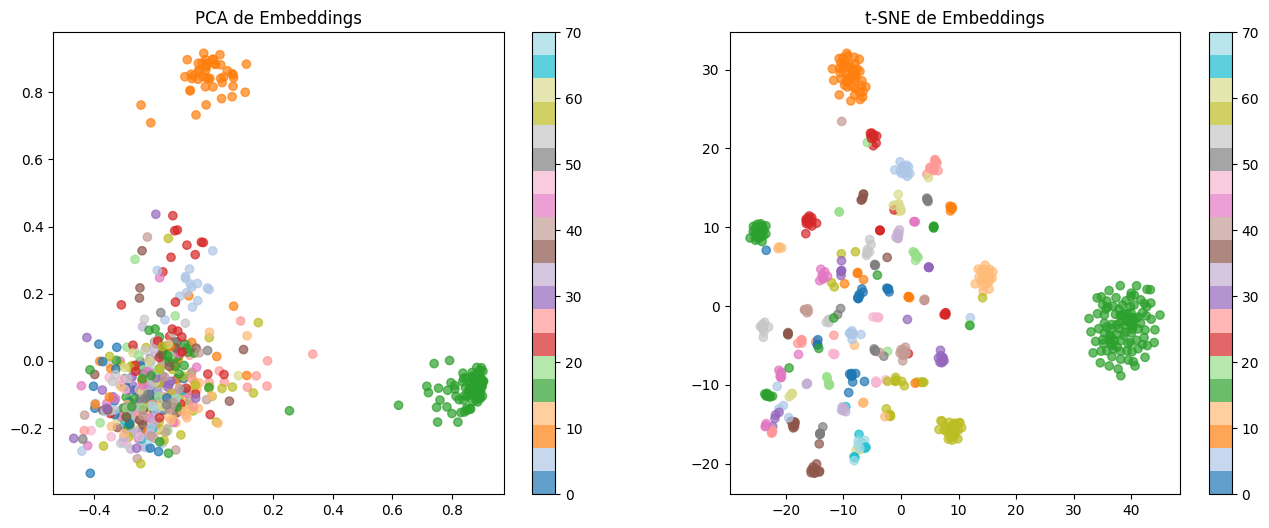

In [14]:
# --- PCA & t-SNE ---
all_embeddings = np.array(all_embeddings)
all_labels_val = np.array(all_labels_val)

# Reducimos dimensionalidad a 2 componentes
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=all_labels_val, cmap='tab20', alpha=0.7)
plt.title("PCA de Embeddings")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=all_labels_val, cmap='tab20', alpha=0.7)
plt.title("t-SNE de Embeddings")
plt.colorbar()

plt.show()

## 8. Guardar el Modelo para el Backend
Exportamos el archivo `.pth` en la carpeta `models/` para que el backend (`face_service.py`) lo pueda levantar.

In [ ]:
import os
os.makedirs("models", exist_ok=True)

# Guardamos únicamente los pesos (state_dict) del modelo entrenado
torch.save(model.state_dict(), "models/face_detection.pth")
print("¡Modelo exportado exitosamente a models/face_detection.pth!")

¡Modelo exportado exitosamente a src/app/models/face_detection.pth!
